In [1]:
import gzip
from collections import defaultdict
import math
import scipy.optimize
import numpy
import string
import random
from sklearn import linear_model
import numpy as np

In [ ]:
import homework3

In [2]:
def readGz(path):
    for l in gzip.open(path, 'rt'):
        yield eval(l)

In [3]:
def readCSV(path):
    f = gzip.open(path, 'rt')
    f.readline()
    for l in f:
        u,b,r = l.strip().split(',')
        r = int(r)
        yield u,b,r

In [4]:
def countRight(a,b,epsilon):
    if len(a) != len(b):
        print("It looks like your solution has the wrong length (got " + str(len(a)) + ", expected "
 + str(len(b)) + ")")
        return 0
    a_ = np.array(a).flatten()
    b_ = np.array(b).flatten()
    right = np.abs(a_ - b_) < epsilon
    return float(sum(right) / len(right))

In [ ]:
# Some data structures that will be useful

In [5]:
allRatings = []
for l in readCSV("/home/scotty/dsc_256/fall_25/assignment_01/train_Interactions.csv"):
    allRatings.append(l)

BadGzipFile: Not a gzipped file (b'us')

In [9]:
import csv
with open('/home/scotty/dsc_256/fall_25/assignment_01/train_Interactions.csv', 'r') as f:
    reader = csv.reader(f)
    # Skip the header if there is one
    header = next(reader)
    # Read the rest of the rows
    data = list(reader)

# Convert to a numpy array
allRatings = np.array(data)

In [10]:

len(allRatings)

200000

In [49]:
ratingsTrain = allRatings[:190000]
ratingsValid = allRatings[190000:]
ratingsPerUser = defaultdict(list)
ratingsPerItem = defaultdict(list)
for u,b,r in ratingsTrain:
    ratingsPerUser[u].append((b,r))
    ratingsPerItem[b].append((u,r))

In [55]:
##################################################
# Rating prediction                              #
##################################################
def getGlobalAverage(trainRatings: list[int]) -> float:
    """
    Compute the global average rating using vectorized NumPy mean.

    Args:
        trainRatings: list of rating values (ints), as built in hw3_runner.py

    Returns:
        float: mean rating value
    """
    # Vectorized mean; np.mean on list returns float
    rates = np.array(trainRatings,dtype=float)
    unique_values, counts = np.unique(rates, return_counts=True)

# Print the unique values and their counts
    for value, count in zip(unique_values, counts):
        print(f"Value: {value}, Count: {count}")
    return float(np.mean(np.array(trainRatings,dtype=float))) if len(trainRatings) > 0 else 0.0


In [56]:
trainRatings = [r[2] for r in ratingsTrain]
len(trainRatings)
#globalAverage = homework3.getGlobalAverage(trainRatings)
globalAverage = getGlobalAverage(trainRatings)

Value: 0.0, Count: 10271
Value: 1.0, Count: 4179
Value: 2.0, Count: 11851
Value: 3.0, Count: 41185
Value: 4.0, Count: 63513
Value: 5.0, Count: 59001


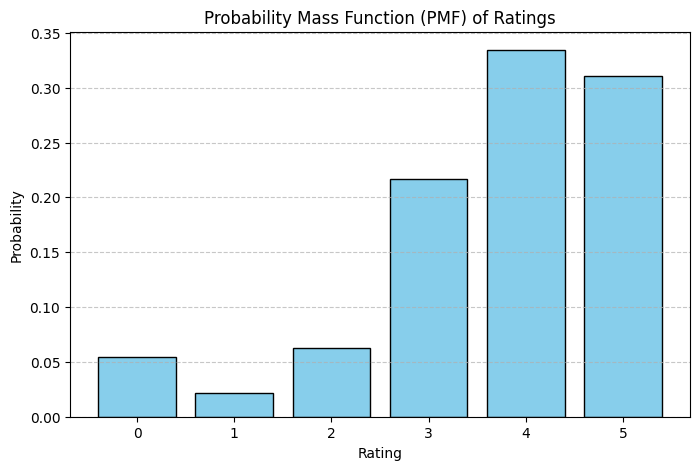

In [20]:

import matplotlib.pyplot as plt
trainRatings = np.array(trainRatings,dtype=float)
values, counts = np.unique(trainRatings, return_counts=True)

# Calculate probabilities
total = sum(counts)
probabilities = [count / total for count in counts]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(values, probabilities, color='skyblue', edgecolor='black')

# Customize the plot
plt.title('Probability Mass Function (PMF) of Ratings')
plt.xlabel('Rating')
plt.ylabel('Probability')
plt.xticks(values)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [57]:
print(ratingsValid[:,2].shape)
def testQ1():
    def trivialValidMSE(ratingsValid, ga):
        val = np.array(ratingsValid[:,2],dtype=float)
        ga_array = np.ones_like(val)*ga
        return float(np.mean((val - ga_array) ** 2))
    def pmfMSE(ratingsValid):   
        # Calculate the PMF
        unique_ratings, counts = np.unique(ratingsValid, return_counts=True)
        pmf = counts / len(ratingsValid)
        # Print the PMF
        for rating, prob in zip(unique_ratings, pmf):
            print(f"Rating: {rating}, Probability: {prob:.3f}")
    #ga = homework3.getGlobalAverage(trainRatings)
    #trivialValidMSE = homework3.trivialValidMSE(ratingsValid, ga)
    ga = getGlobalAverage(trainRatings)
    trivialValidMSE = trivialValidMSE(ratingsValid, ga)
    print("average = " + str(ga))
    print("validation MSE = " + str(trivialValidMSE))

(10000,)


In [70]:
import numpy as np

def testQ1():
    def trivialValidMSE(ratingsValid, ga):
        # Extract the ratings column (assuming it's the 3rd column, index 2)
        val = np.array(ratingsValid)[:].astype(float)
        ga_array = np.ones_like(val) * ga
        return float(np.mean((val - ga_array) ** 2))

    def pmfMSE(trainRatings, ratingsValid):
        # Convert to NumPy arrays
        trainRatings = np.array(trainRatings)
        ratingsValid = np.array(ratingsValid)

        # Calculate the PMF from the training data (3rd column, index 2)
        train_ratings = trainRatings.astype(float)
        unique_ratings, counts = np.unique(train_ratings, return_counts=True)
        pmf = counts / len(train_ratings)

        # Print the PMF
        print("PMF of training data:")
        for rating, prob in zip(unique_ratings, pmf):
            print(f"Rating: {rating}, Probability: {prob:.3f}")

        # Predict the most likely rating for validation data
        most_likely_rating = unique_ratings[np.argmax(pmf)]
        validation_predictions = np.full(len(ratingsValid), most_likely_rating)

        # Extract validation ratings (3rd column, index 2)
        validation_ratings = ratingsValid.astype(float)

        # Calculate MSE for validation predictions
        mse = np.mean((validation_ratings - validation_predictions) ** 2)
        return mse

    # Convert trainRatings and ratingsValid to NumPy arrays
    #trainRatings = np.array(trainRatings)
    #ratingsValid = np.array(ratingsValid)

    # Calculate global average
    ga = getGlobalAverage(trainRatings)

    # Calculate trivial MSE
    trivial_mse = trivialValidMSE(ratingsValid, ga)
    print("Global average = " + str(ga))
    print("Trivial validation MSE = " + str(trivial_mse))

    # Calculate PMF MSE
    pmf_mse = pmfMSE(trainRatings, ratingsValid)
    print("PMF validation MSE = " + str(pmf_mse))

# Example function to calculate global average
def getGlobalAverage(trainRatings):
    return np.mean(trainRatings[:, 2].astype(float))

# Call the test function
testQ1()


TypeError: list indices must be integers or slices, not tuple

In [64]:
testQ1()

Value: 0.0, Count: 10271
Value: 1.0, Count: 4179
Value: 2.0, Count: 11851
Value: 3.0, Count: 41185
Value: 4.0, Count: 63513
Value: 5.0, Count: 59001
Global average = 3.6868052631578947
Trivial validation MSE = 1.680211317922438


TypeError: list indices must be integers or slices, not tuple

Value: 0.0, Count: 10271
Value: 1.0, Count: 4179
Value: 2.0, Count: 11851
Value: 3.0, Count: 41185
Value: 4.0, Count: 63513
Value: 5.0, Count: 59001
average = 3.6868052631578947
validation MSE = 1.680211317922438
Value: 0.0, Count: 507
Value: 1.0, Count: 217
Value: 2.0, Count: 602
Value: 3.0, Count: 2247
Value: 4.0, Count: 3389
Value: 5.0, Count: 3038


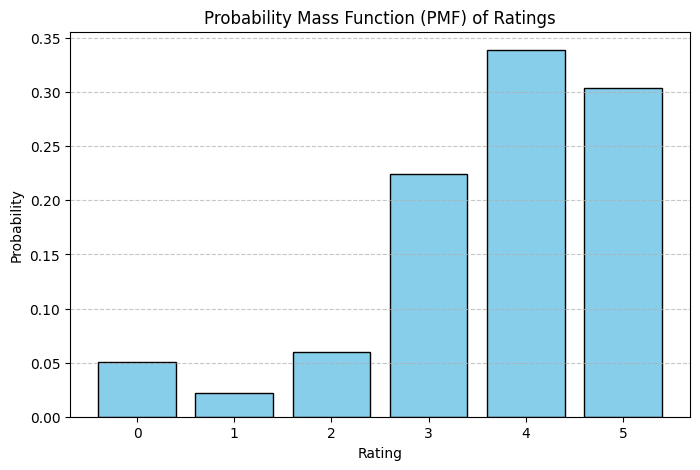

In [47]:
testQ1()
vals = ratingsValid = np.array(ratingsValid[:,2],dtype=float)
values, counts = np.unique(vals, return_counts=True)

for value, count in zip(values, counts):
    print(f"Value: {value}, Count: {count}")

# Calculate probabilities
total = sum(counts)
probabilities = [count / total for count in counts]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(values, probabilities, color='skyblue', edgecolor='black')

# Customize the plot
plt.title('Probability Mass Function (PMF) of Ratings')
plt.xlabel('Rating')
plt.ylabel('Probability')
plt.xticks(values)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [ ]:
def iterateN(which, alpha, betaU, betaI, lamb, N):
    for i in range(N):
        alpha = which.alphaUpdate(ratingsTrain, alpha, betaU, betaI, lamb)
        betaU = which.betaUUpdate(ratingsPerUser, alpha, betaU, betaI, lamb)
        betaI = which.betaIUpdate(ratingsPerItem, alpha, betaU, betaI, lamb)
        mse, mseReg = which.msePlusReg(ratingsTrain, alpha, betaU, betaI, lamb)
        print("Iteration " + str(i + 1))
        print("  MSE = " + str(mse))
        print("  regularized objective = " + str(mseReg))
    return alpha, betaU, betaI, mse, mseReg

In [ ]:
def testModel(which):
    betaU = {}
    betaI = {}
    for u in ratingsPerUser:
        betaU[u] = 0

    for b in ratingsPerItem:
        betaI[b] = 0

    alpha = globalAverage # Could initialize anywhere, this is a guess
    
    alpha, betaU, betaI, mse, mseReg = iterateN(which, alpha, betaU, betaI, 1.0, 1)
    validMSE = which.validMSE(ratingsValid, alpha, betaU, betaI)
    
    return alpha, betaU, betaI, mse, mseReg, validMSE

In [ ]:
def testQ2():
    alpha, betaU, betaI, mse, mseReg, validMSE = testModel(homework3)
    print("validMSE = " + str(validMSE))

In [ ]:
testQ2()

In [ ]:
def testQ3():
    betaU = {}
    betaI = {}
    for u in ratingsPerUser:
        betaU[u] = 0

    for b in ratingsPerItem:
        betaI[b] = 0

    alpha = globalAverage # Could initialize anywhere, this is a guess
    
    alpha, betaU, betaI = homework3.goodModel(ratingsTrain, ratingsPerUser, ratingsPerItem, alpha, betaU, betaI)
    validMSE = homework3.validMSE(ratingsValid, alpha, betaU, betaI)
    
    print("validMSE = " + str(validMSE))

In [ ]:
testQ3()

In [ ]:
##################################################
# Read prediction                                #
##################################################

In [ ]:
# From baseline code
bookCount = defaultdict(int)
totalRead = 0

for user,book,_ in readCSV("train_Interactions.csv.gz"):
    bookCount[book] += 1
    totalRead += 1

mostPopular = [(bookCount[x], x) for x in bookCount]
mostPopular.sort()
mostPopular.reverse()

In [ ]:
def testQ4():
    readValid, notRead = homework3.generateValidation(allRatings, ratingsValid)
    print("Should be equal: " + str((len(readValid), len(notRead), len(ratingsValid))))

In [ ]:
testQ4()

In [ ]:
def testQ5():
    return1 = homework3.baseLineStrategy(mostPopular, totalRead)
    better = homework3.improvedStrategy(mostPopular, totalRead)
    
    readValid, notRead = homework3.generateValidation(allRatings, ratingsValid)
    
    correctA = homework3.evaluateStrategy(return1, readValid, notRead)
    correctB = homework3.evaluateStrategy(better, readValid, notRead)
    
    print("Accuracy (simple strategy) = " + str(correctA))
    print("Accuracy (better strategy) = " + str(correctB))

In [ ]:
testQ5()

In [ ]:
def testQ6():
    readValid, notRead = homework3.generateValidation(allRatings, ratingsValid)
    
    for (u,b) in list(readValid)[:20] + list(notRead)[:20]:
        a = homework3.jaccardThresh(u,b,ratingsPerItem,ratingsPerUser)
        print("Jaccard-based predictor for " + str((u,b)) + " = " + str(a))

    # This is slow (so the autograder doesn't run it) but you should run it at home once you have a good solution
    #homework3.writePredictionsRead(ratingsPerItem, ratingsPerUser)

In [ ]:
testQ6()

In [ ]:
##################################################
# Category prediction                            #
##################################################

In [ ]:
data = []

for d in readGz("train_Category.json.gz"):
    data.append(d)
    # Just use a little data to make things faster...
    if len(data) > 10000:
        break

In [ ]:
wordCount = defaultdict(int)
punctuation = set(string.punctuation)
for d in data:
    r = ''.join([c for c in d['review_text'].lower() if not c in punctuation])
    for w in r.split():
        wordCount[w] += 1

counts = [(wordCount[w], w) for w in wordCount]
counts.sort()
counts.reverse()

In [ ]:
NW = 500 # dictionary size

In [ ]:
words = [x[1] for x in counts[:NW]]

In [ ]:
wordId = dict(zip(words, range(len(words))))
wordSet = set(words)

In [ ]:
def testQ7():
    f1 = homework3.featureCat(data[0], words, wordId, wordSet)
    
    print("Feature vector = " + str(f1))

In [ ]:
testQ7()

In [ ]:
def testQ8():
    X = [homework3.featureCat(d, words, wordId, wordSet) for d in data]
    y = [d['genreID'] for d in data]
    
    Xtrain = X[:9*len(X)//10]
    ytrain = y[:9*len(y)//10]
    Xvalid = X[9*len(X)//10:]
    yvalid = y[9*len(y)//10:]
    
    mod = linear_model.LogisticRegression(C=1)
    mod.fit(Xtrain, ytrain)
    pred = mod.predict(Xvalid)
    correctA = pred == yvalid
    correctA = sum(correctA) / len(correctA)
    
    X = homework3.betterFeatures(data)
    Xtrain = X[:9*len(X)//10]
    Xvalid = X[9*len(X)//10:]
    
    mod = linear_model.LogisticRegression(C=1)
    mod.fit(Xtrain, ytrain)
    pred = mod.predict(Xvalid)
    correctB = pred == yvalid
    correctB = sum(correctB) / len(correctB)
    
    sc = correctA < (correctB * 0.99)

    data_test = []
    for d in readGz("test_Category.json.gz"):
        data_test.append(d)
    
    Xtest = homework3.betterFeatures(data_test)
    pred_test = mod.predict(Xtest)
    
    homework3.writePredictionsCategory(pred_test)
    
    if sc:
        print("Looks like your solution is better")
    else:
        print("Looks like your solution is not better")

In [ ]:
testQ8()